In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("smartcart_customers.csv")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing

### Handling missing values

In [7]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

### Feature Engineering

In [9]:
# Age
df["Age"] = 2026-df["Year_Birth"]

In [10]:
# Customer tenure

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [11]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [12]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [13]:
# spending total
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

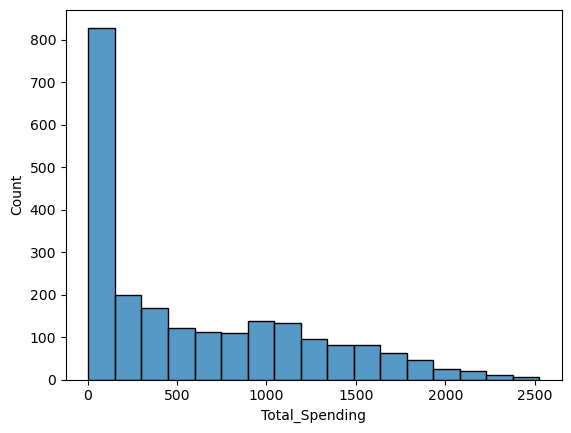

In [14]:
sns.histplot(data = df, x = "Total_Spending")
plt.show()

### Most customers fall into the low-to-mid spending range, indicating that the majority are budget-conscious. Only a small segment contributes to high revenue, suggesting potential for targeted premium marketing.


In [29]:
category_spending = {
    'Wines': df['MntWines'].sum(),
    'Fruits': df['MntFruits'].sum(),
    'Meat': df['MntMeatProducts'].sum(),
    'Fish': df['MntFishProducts'].sum(),
    'Sweets': df['MntSweetProducts'].sum(),
    'Gold': df['MntGoldProds'].sum()
}

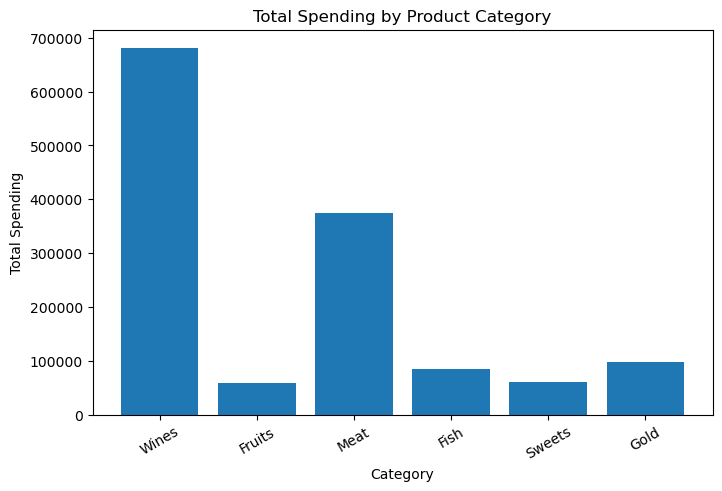

In [30]:
plt.figure(figsize=(8,5))
plt.bar(category_spending.keys(), category_spending.values())
plt.title("Total Spending by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Spending")
plt.xticks(rotation=30)
plt.show()

### Customers spend significantly more amount on wines than other categories. This shows a strong preferences for premium or lifesytle products.

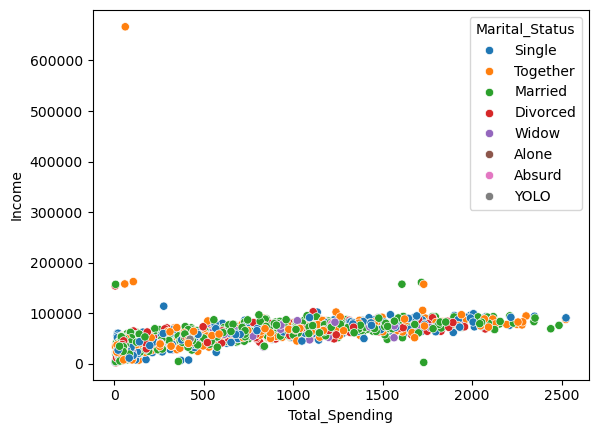

In [16]:
sns.scatterplot(data = df,x = "Total_Spending", y = "Income",hue = "Marital_Status")
plt.show()

### A positive correlation is observed between income and total spending, indicating that higher-income customers tend to spend more. However, some high-income customers show low spending behavior, making them potential targets for marketing campaigns.

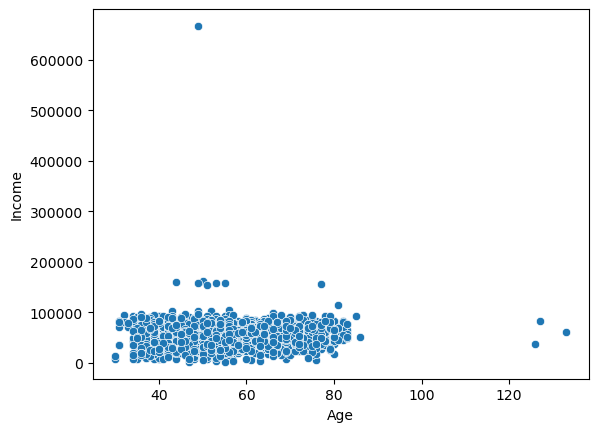

In [19]:
sns.scatterplot(data = df,x = "Age", y = "Income")
plt.show()

### Plot shows person in their 30s and 40s spend more money. This insight help us to target audience

In [20]:
## Total Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [21]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [22]:
# Education

df["Education"] = df["Education"].replace({
    "Graduation": "Graduate", "PhD": "PostGraduate",
    "Master": "PostGraduate", "2n Cycle": "UnderGraduate",
    "Basic": "UnderGraduate"
})

In [23]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [24]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Alone": "Alone",
    "Absurd": "Alone", "YOLO": "Alone"
})

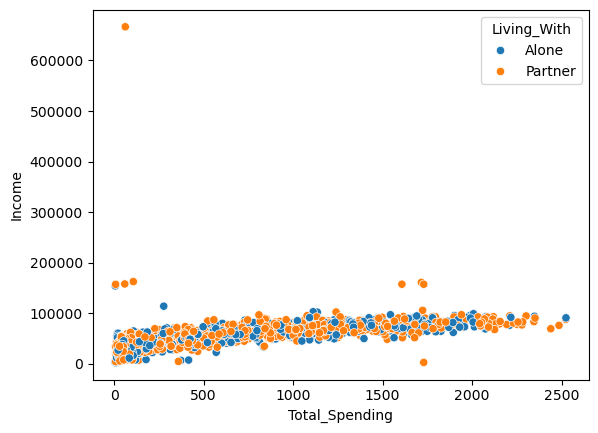

In [25]:
sns.scatterplot(data = df,x = "Total_Spending", y = "Income",hue = "Living_With")
plt.show()

In [26]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [27]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts","MntGoldProds"]

In [28]:
df_cleaned = df.drop(columns=cols)

In [20]:
df_cleaned.shape

(2240, 15)

In [21]:
print("total lenght with outlier", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)]

print("Total length without outlier", len(df_cleaned))


total lenght with outlier 2240
Total length without outlier 2236


In [22]:
corr = df_cleaned.corr(numeric_only=True)

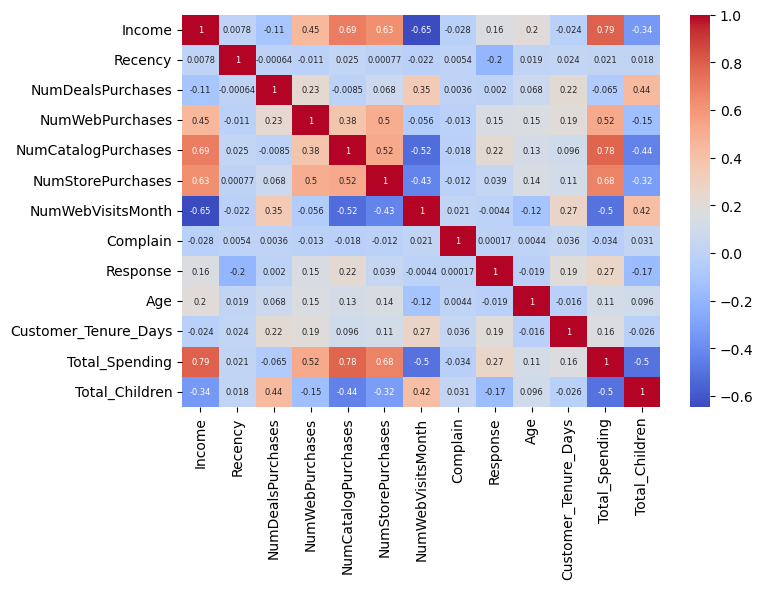

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)
plt.tight_layout()

# Encoding 

In [24]:
from sklearn.preprocessing import OneHotEncoder

In [25]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

end_cols = ohe.fit_transform(df_cleaned[cat_cols])



In [26]:
encoded_df = pd.DataFrame(end_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [27]:
df_encoded = pd.concat([df_cleaned.drop(columns =cat_cols), encoded_df], axis=1)

In [28]:
df_encoded.shape


(2236, 18)

# Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
X = df_encoded

In [31]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [32]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]])

# Visualization

In [33]:


from sklearn.decomposition import PCA


In [34]:
# 2D

pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_scaled)



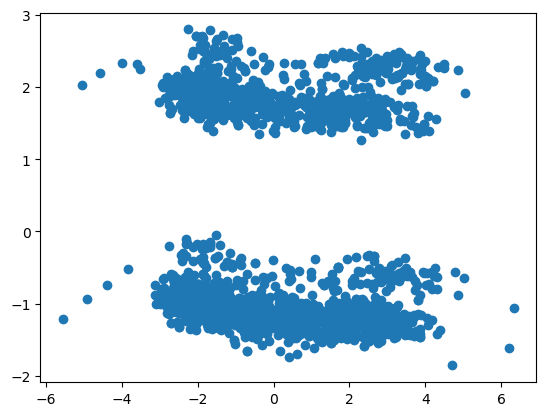

In [35]:
plt.scatter(x_pca[:, 0], x_pca[:, 1])

In [36]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

In [37]:
# 3D

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)



Text(0.5, 0.92, '3D Projection')

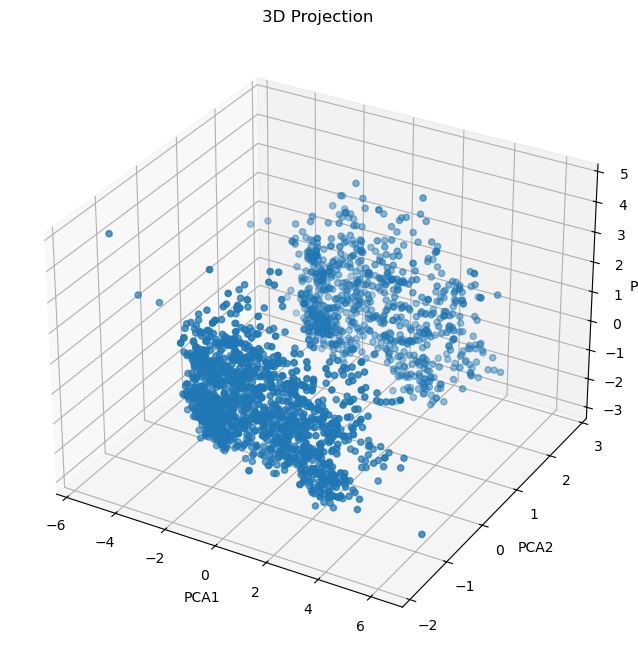

In [38]:
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0], X_pca[:, 1], X_pca[:, 2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")

## choose the value of k

### 1. elbow method



In [39]:
from sklearn.cluster import KMeans
wcss =[]

for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)


    

C:\Users\anuj verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\anuj verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\anuj verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\anuj verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a m

In [40]:
from kneed import KneeLocator

knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")

optimal_k = knee.elbow

print(optimal_k)

4


Text(0.5, 1.0, 'elbow plot')

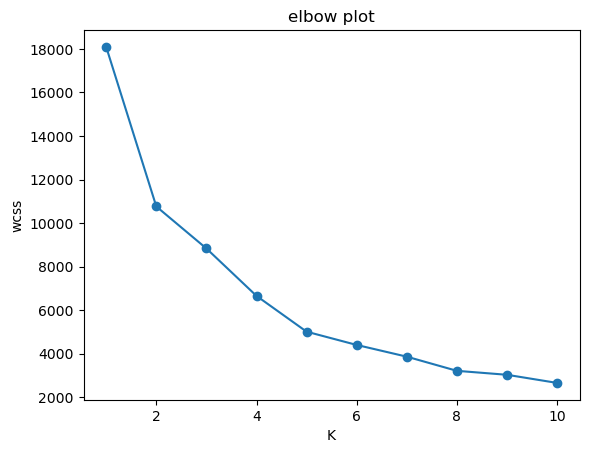

In [41]:
# plot 

plt.plot(range(1,11), wcss, marker="o", )
plt.xlabel("K")
plt.ylabel("wcss")
plt.title("elbow plot")

In [42]:
# silhouette score

from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)
    

C:\Users\anuj verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\anuj verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\anuj verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\anuj verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a m

Text(0.5, 1.0, 'silhouette score')

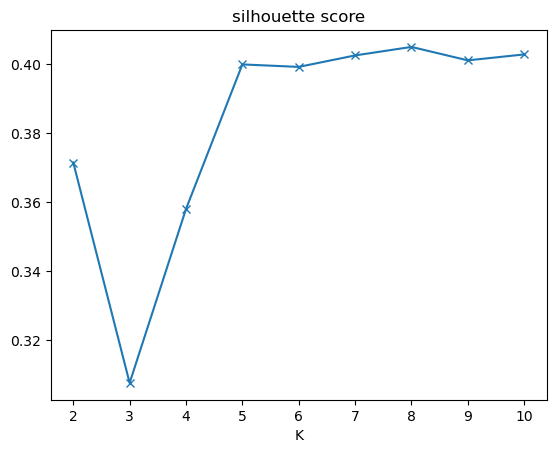

In [43]:
# plot 

plt.plot(range(2,11), scores, marker="x")
plt.xlabel("K")
plt.title("silhouette score")

Text(0, 0.5, 'silhouette score')

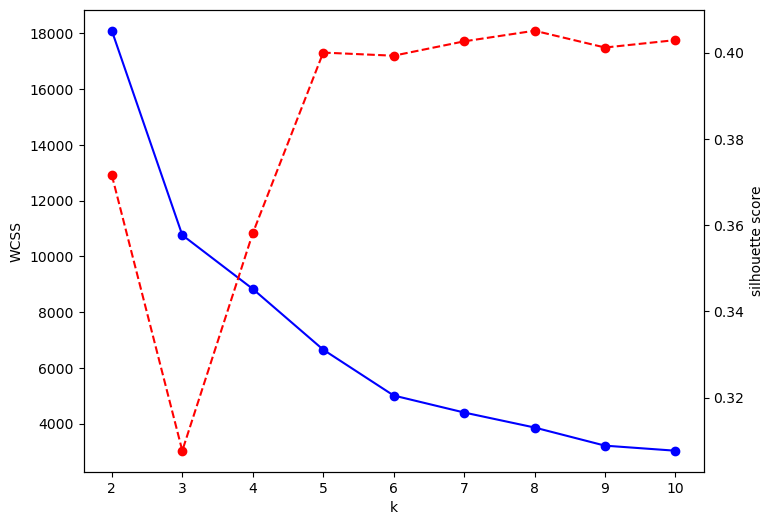

In [44]:
# combined plot
k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()

ax2.plot(k_range, scores[:len(k_range)], marker="o", color="red", linestyle="--")
ax2.set_ylabel("silhouette score")

# clustering

In [45]:
# kmeans

kmeans = KMeans(n_clusters=4, random_state=42)

labels_kmeans = kmeans.fit_predict(X_pca)


C:\Users\anuj verma\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


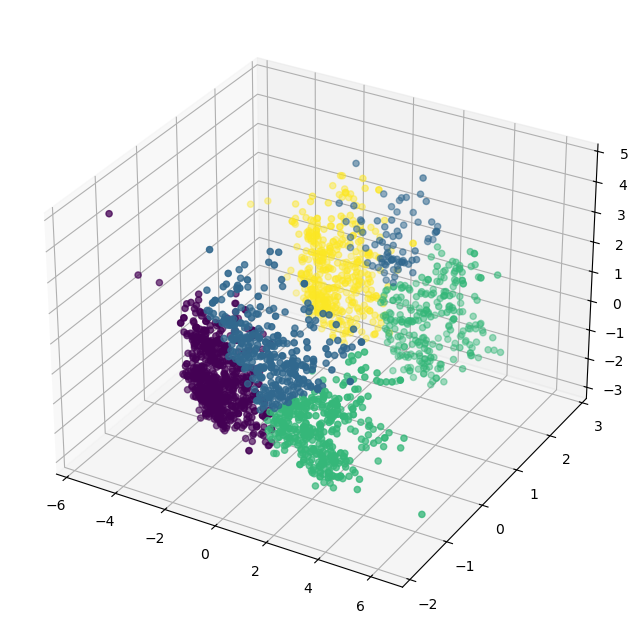

In [46]:
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

In [47]:
# Agglomerative clustering

from sklearn.cluster import AgglomerativeClustering

In [48]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")

labels_agg = agg_clf.fit_predict(X_pca)


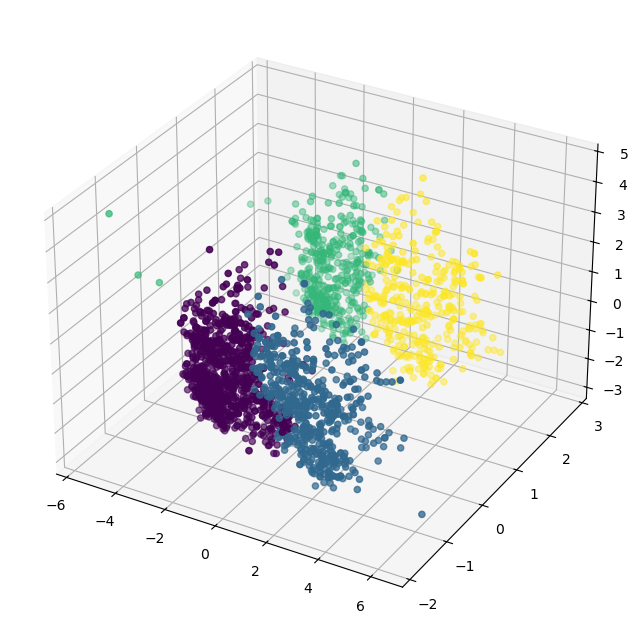

In [49]:
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

# Characterization of cluster

In [57]:
X["Cluster"] = labels_agg


In [58]:
X.head()


,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,Living_With_Alone,Living_With_Partner,Cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='Cluster', ylabel='count'>

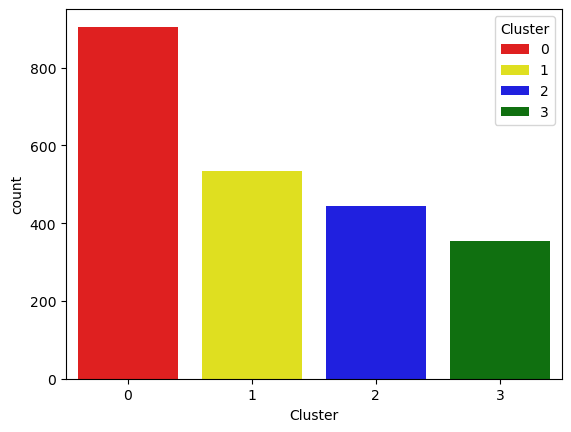

In [59]:
pal = ["red", "yellow", "blue", "green"]

sns.countplot(x=X["Cluster"], palette=pal, hue=X["Cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

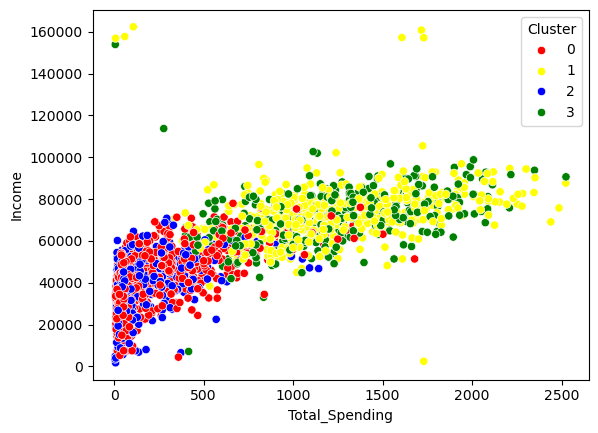

In [60]:
sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["Cluster"], palette=pal)

In [62]:
Cluster_summary = X.groupby("Cluster").mean()
print(Cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
Cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
Cluster         

## Insights from Clustering

### Clusters:
- Cluster 0: Low income, low spending (Family Customers)
- Cluster 1: High income, high spending (Premium Customers)
- Cluster 2: Moderate income, family-oriented (Value Seekers)
- Cluster 3: Moderate income, High spending (High value customers)

## 📊 Customer Segmentation Summary

| Cluster | Income & Spending | Family Type | Age | Web Behavior | Purchase Behavior | Customer Type |
|--------|------------------|-------------|-----|--------------|------------------|--------------|
| **Cluster 0** | Low income, low spending | Living with partner, more children | Moderate | High web visits, poor response | Low web, store, and catalog purchases | Budget Customers |
| **Cluster 1** | High income, high spending | Living with partner, fewer children | High | Low web visits, average response | High store and web purchases | Premium Customers |
| **Cluster 2** | Moderate income, low spending | Living alone, more children | Moderate | High web visits, average response | Low purchases across all channels | Low Engagement Customers |
| **Cluster 3** | Moderate income, high spending | Living alone, fewer children | High | High web visits, best response | High store and web purchases | High Potential Customers |

### Insigths:
- Cluster 0 represents budget customers with low purchasing power and poor engagement despite frequent website visits. These customers may be price-sensitive and require discounts to convert.

- Cluster 1 consists of premium customers with high income and strong purchasing behavior. They contribute significantly to revenue and should be targeted with premium offerings and loyalty programs.

- Cluster 2 shows low engagement despite high website visits. These customers are likely browsing but not converting, indicating a need for better targeting or personalized recommendations.

- Cluster 3 represents highly engaged and responsive customers with strong purchasing behavior. They are ideal targets for upselling and personalized marketing strategies.

## Business Insights and Recommendation

- Offer discounts and promotional campaigns to Cluster 0 to improve conversion rates.
- Focus on retention strategies and premium services for Cluster 1 to maximize revenue.
- Improve personalization and recommendation systems for Cluster 2 to convert browsing into purchases.
- Target Cluster 3 with upselling and cross-selling strategies, as they show high engagement and responsiveness.

#### This analysis can directly help businesses increase conversion rates and optimize marketing ROI.